# 2019 German GP(Hockenheim) - Strategy Post Mortem: Discipline vs. Disaster in the Wet

## The Racing Question:
Sebastian Vettel recovered from P20 to P2 in a race where Lewis Hamilton, starting from pole, finished outside the points. What seperated a recovery drive from a race-wrecking one, when both drivers faced the same treacherous, ever-changing conditions?

## What Happened - Hamilton:
 - Lap 28: Pits under VSC(Norris retired) for a clean ~23s pit stop.
 - Lap 29: Track conditions deteriorate rapidly; Hamilton aquaplanes and hits the barrier(at Turn 16), damaging his front wing. A full Safety Car is deployed; he limps back into the pits for a messy ~69s pit stop(Mercedes pit crew were unaware of the crash AND were indecisive on which tire compound to put on) but enters the wrong side of the pit bollard in the process.
 - Lap 34: Stewards issue a 5-second penalty for the bollard infringement.
 - Lap 47: Hamilton serves his 5-second penalty during a routine pit stop(~ 27s, roughly 5s over the baseline)
 - Net Effect: A single driving error cascaded into a damaged car, an entra-long repair stop, and a penalty; costing well over 100 seconds relative to a clean race.

 ## What Happened - Vettel:
 - Five fast pit stops across the race(laps: 2, 23, 28, 41, 47), every single one in the 19.6-22.0 second range; no errors, no damage, and no penalties.
 - Early Laps: recovered from P18 to P9 by lap 8, largely benefiting from other cars' incidents in the trecherous opening laps of the Grand Prix.
 - Laps 44-47: gained significant track position (P10 --> P3) by staying out slightly longer than rivals during the drying-track tire scramble, before making his own pit stop.
 - Laps 53-64: climbed from P6 to P2 with zero pit stops(pure race pace, picking off Sainz, Stroll, and Kvyat one by one in the closing laps.)

 ## Why It Matters:
 Two drivers, same trecherous conditons, same number of realistic opportunities to gain or lose time. Vettel's crew delivered five metronomic stops and let him capitalize on timing and pace. Hamilton's race on the other hand was decided in a single moment on lap 29. The crash did not just cost ~69s but it also triggered a penalty that cost even more time later in the race.

 ## Strategist Takeaway:
 In changeable conditions, the biggest strategic edge often isn't a clever tire call, it's simply not giving anything back. Excecution discipline(consistent, error-free pit stops) compounded over the Grand Prix can outweigh a single bold strategic gamble. Conversely, a single driving error doesn't just cost the moment it happens, it can cascade into penalties and lost track positions for the rest of the race.

 ## A Note on Method:
 Cross-referencing FastF1's 'race_control_messages' against pit stop durations(calculated by correctly pairing 'PitInTime' with the following lap's 'PitOutTime') let me pinpoint exactly which stops were "normal" vs. affected by incidents or penalties; without this, raw lap-times or gap charts alone would have made Hamilton's laps 28-30 swing look like a strategy failure, when it was actually a single on-track error.           

In [1]:
#imports

import fastf1
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
fastf1.Cache.enable_cache('../data/cache')
session = fastf1.get_session(2019, 'Germany', 'R')
session.load()

print(session.event['EventName'])
print(session.event['EventDate'])

core           INFO 	Loading data for German Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cac

German Grand Prix
2019-07-28 00:00:00


In [5]:
# Picked Sebastian Vettel & Hamilton for this analysis.

laps = session.laps
vet_laps = laps.pick_drivers('VET')
ham_laps = laps.pick_drivers('HAM')

print("Vettel Laps:", len(vet_laps))
print("Hamilton Laps:", len(ham_laps))

cols = ['LapNumber', 'LapTime', 'Compound', 'PitInTime', 'PitOutTime', 'TrackStatus']

Vettel Laps: 64
Hamilton Laps: 64


In [6]:
#Finding pit stop for both drivers

vet_pit_laps = vet_laps[vet_laps['PitInTime'].notna()]
ham_pit_laps = ham_laps[ham_laps['PitInTime'].notna()]

print("Vettel Pit Stops:")
print(vet_pit_laps[cols])

print("\nHamilton Pit Stops:")
print(ham_pit_laps[cols])

Vettel Pit Stops:
     LapNumber                LapTime      Compound              PitInTime  \
555        2.0 0 days 00:01:47.381000           WET 0 days 00:43:38.470000   
576       23.0 0 days 00:01:38.863000  INTERMEDIATE 0 days 01:17:40.402000   
581       28.0 0 days 00:02:02.599000          SOFT 0 days 01:26:41.083000   
594       41.0 0 days 00:01:54.838000  INTERMEDIATE 0 days 01:49:21.192000   
600       47.0 0 days 00:01:31.812000  INTERMEDIATE 0 days 02:00:14.619000   

    PitOutTime TrackStatus  
555        NaT          14  
576        NaT           1  
581        NaT       67124  
594        NaT          24  
600        NaT           1  

Hamilton Pit Stops:
     LapNumber                LapTime      Compound              PitInTime  \
492        3.0 0 days 00:02:01.968000           WET 0 days 00:45:13.431000   
517       28.0 0 days 00:01:58.286000  INTERMEDIATE 0 days 01:24:58.326000   
518       29.0                    NaT          SOFT 0 days 01:27:33.133000   
536   

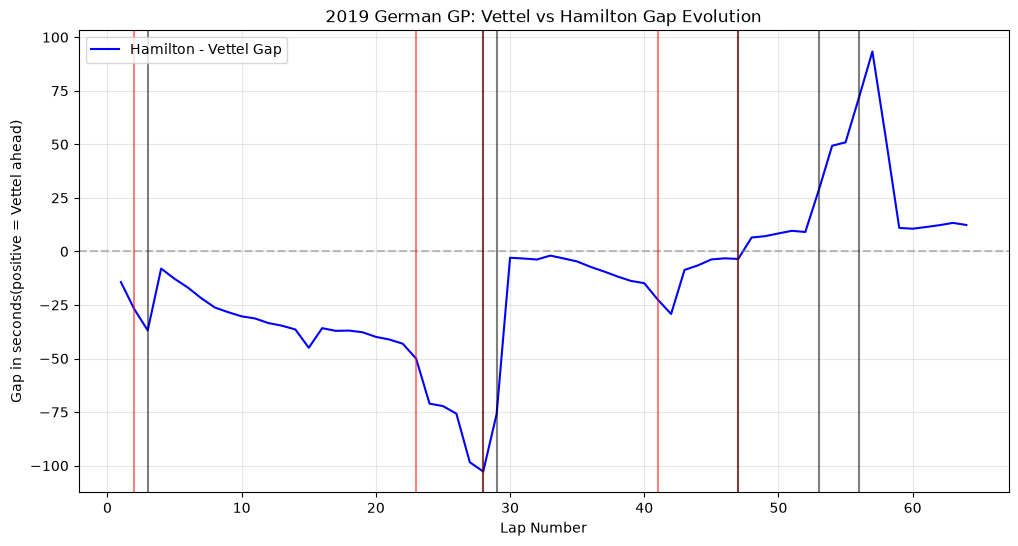

In [10]:
#Building a gap chart between Hamilton and Vettel

merged = pd.merge(
    vet_laps[['LapNumber', 'Time']],
    ham_laps[['LapNumber', 'Time']],
    on='LapNumber',
    suffixes=('_VET', '_HAM')
)

merged['Gap_HAM_minus_VET'] = (merged['Time_HAM'] - merged['Time_VET']).dt.total_seconds()

plt.figure(figsize=(12, 6))
plt.plot(merged['LapNumber'], merged['Gap_HAM_minus_VET'], label='Hamilton - Vettel Gap', color='blue')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

for lap in [2,23,28,41,47]:
    plt.axvline(lap, color='red', alpha=0.5)

for lap in [3,28,29,47,53,56]:
    plt.axvline(lap, color='black', alpha=0.5)

plt.xlabel('Lap Number')
plt.ylabel('Gap in seconds(positive = Vettel ahead)')
plt.title('2019 German GP: Vettel vs Hamilton Gap Evolution')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [11]:
#pulling up race control messages to get a clearer picture(especially for Hamilton's pit stop(s))

rcm = session.race_control_messages
pd.set_option('display.max_rows', None)
print(rcm[['Lap','Category', 'Message']])

    Lap   Category                                            Message
0     1      Other                                    PIT EXIT CLOSED
1     1      Other              RISK OF RAIN FOR THIS SESSION IS 100%
2     1      Other  FORMATION LAPS WILL COMMENCE ON TIME AT 15:10 ...
3     1      Other         SAFETY CAR WILL ENTER PITS: STANDING START
4     1       Flag                        GREEN LIGHT - PIT EXIT OPEN
5     3  SafetyCar                                SAFETY CAR DEPLOYED
6     3       Flag                   DOUBLE YELLOW IN TRACK SECTOR 10
7     4  SafetyCar                             SAFETY CAR IN THIS LAP
8     4       Flag                           CLEAR IN TRACK SECTOR 10
9     4       Flag                                        TRACK CLEAR
10    8      Other  PIT LANE INCIDENT INVOLVING CARS 16 (LEC) AND ...
11   13      Other  PIT LANE INCIDENT INVOLVING CAR 16 (LEC) AND 8...
12   15       Flag                           YELLOW IN TRACK SECTOR 9
13   15   CarEvent  

In [12]:
penalty_msgs = rcm[rcm['Message'].str.contains('PENALTY', case=False, na=False)]
print(penalty_msgs[['Lap', 'Category', 'Message']])

    Lap Category                                            Message
61   34    Other  5 SECOND TIME PENALTY FOR CAR 44 (HAM) - WRONG...


In [14]:
#comparing pit-in & pit-out times for hamilton to see when he served his 5s penalty

#ham_pits = ham_laps[ham_laps['PitInTime'].notna()].copy()
#ham_pits['PitDuration'] = (ham_pits['PitOutTime'] - ham_pits['PitInTime']).dt.total_seconds()
#print(ham_pits[['LapNumber', 'PitInTime', 'PitOutTime', 'PitDuration']])


ham_pits_in = ham_laps[ham_laps['PitInTime'].notna()][['LapNumber', 'PitInTime']].copy()
ham_pits_out = ham_laps[ham_laps['PitOutTime'].notna()][['LapNumber', 'PitOutTime']].copy()

# Shift the out-lap number back by 1 so it aligns with the lap the driver pitted on
ham_pits_out['LapNumber'] = ham_pits_out['LapNumber'] - 1

ham_pit_durations = pd.merge(ham_pits_in, ham_pits_out, on='LapNumber', how='left')
ham_pit_durations['PitDuration'] = (ham_pit_durations['PitOutTime'] - ham_pit_durations['PitInTime']).dt.total_seconds()

print(ham_pit_durations)

   LapNumber              PitInTime             PitOutTime  PitDuration
0        3.0 0 days 00:45:13.431000 0 days 00:45:33.677000       20.246
1       28.0 0 days 01:24:58.326000 0 days 01:25:21.327000       23.001
2       29.0 0 days 01:27:33.133000 0 days 01:28:42.154000       69.021
3       47.0 0 days 02:00:11.058000 0 days 02:00:38.121000       27.063
4       53.0 0 days 02:08:53.646000 0 days 02:09:13.653000       20.007
5       56.0 0 days 02:13:29.390000 0 days 02:13:48.983000       19.593


In [15]:
#Analyzing Vettel's pit stop timeline & durations

vet_pits_in = vet_laps[vet_laps['PitInTime'].notna()][['LapNumber', 'PitInTime']].copy()
vet_pits_out = vet_laps[vet_laps['PitOutTime'].notna()][['LapNumber', 'PitOutTime']].copy()

vet_pits_out['LapNumber'] = vet_pits_out['LapNumber'] - 1

vet_pit_durations = pd.merge(vet_pits_in, vet_pits_out, on='LapNumber', how='left')
vet_pit_durations['PitDuration'] = (vet_pit_durations['PitOutTime'] - vet_pit_durations['PitInTime']).dt.total_seconds()

print(vet_pit_durations)

   LapNumber              PitInTime             PitOutTime  PitDuration
0        2.0 0 days 00:43:38.470000 0 days 00:43:58.553000       20.083
1       23.0 0 days 01:17:40.402000 0 days 01:18:01.150000       20.748
2       28.0 0 days 01:26:41.083000 0 days 01:27:03.098000       22.015
3       41.0 0 days 01:49:21.192000 0 days 01:49:42.428000       21.236
4       47.0 0 days 02:00:14.619000 0 days 02:00:34.199000       19.580


In [16]:
#This shows Vettel's track position over the Grand Prix

vet_positions = vet_laps[['LapNumber', 'Position']].copy()
print(vet_positions)

     LapNumber  Position
554        1.0      14.0
555        2.0      12.0
556        3.0      18.0
557        4.0      12.0
558        5.0      10.0
559        6.0       8.0
560        7.0       8.0
561        8.0       7.0
562        9.0       7.0
563       10.0       7.0
564       11.0       7.0
565       12.0       7.0
566       13.0       7.0
567       14.0       7.0
568       15.0       7.0
569       16.0       7.0
570       17.0       7.0
571       18.0       7.0
572       19.0       7.0
573       20.0       7.0
574       21.0       7.0
575       22.0       7.0
576       23.0       8.0
577       24.0      11.0
578       25.0      11.0
579       26.0      10.0
580       27.0       8.0
581       28.0       7.0
582       29.0       8.0
583       30.0       8.0
584       31.0       8.0
585       32.0       8.0
586       33.0       8.0
587       34.0       8.0
588       35.0       8.0
589       36.0       8.0
590       37.0       8.0
591       38.0       8.0
592       39.0       7.0


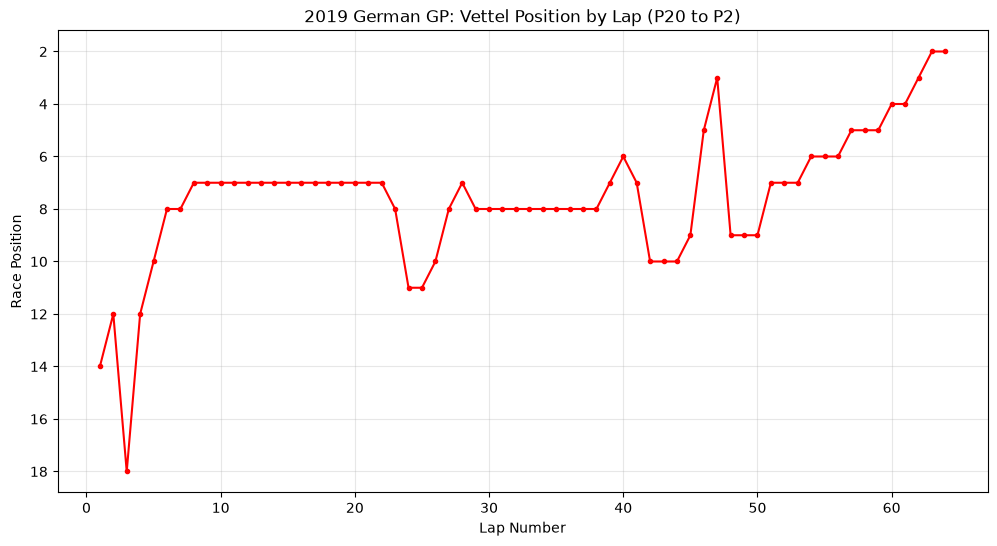

In [21]:
#Plotting Vettel's climb from P20 --> P2 as the Grand Prix progressed
plt.figure(figsize=(12, 6))
plt.plot(vet_positions['LapNumber'], vet_positions['Position'], color='red', marker='o', markersize=3)

plt.gca().invert_yaxis()  # Position 1 should be at the top of the chart, not the bottom
plt.xlabel('Lap Number')
plt.ylabel('Race Position')
plt.title('2019 German GP: Vettel Position by Lap (P20 to P2)')
plt.grid(alpha=0.3)
plt.show()